# BASIC

In [40]:
import numpy as np
import networkx as nx
import gcmi
import hypernetx as hnx
from turtle import width
import csv
import itertools
import matplotlib.pyplot as plt
import random
import pandas as pd
from pandas import *
from tabulate import tabulate
import math
import community as comm
from tqdm import tqdm
#Reading the whole data from file
y=read_csv('BSI100.csv')


#Reading the companies
Companies=[]

for row in y:
    Companies.append(row)
Companies.remove('Dates')

#Reading the data points into list
fc=[]
for i in Companies:
    fc.append(y[i].tolist())

#Selecting the data for the particular time  period    
    
    
#Removing the data before 08/02/2022
for j in range(0,len(Companies)):
    for k in range(1,5044):
        del fc[j][5042-k]


#Removing the data after  25/03/2022
for j in range(0,len(Companies)):
    for k in range(1,185):
        del fc[j][3329-k]


#Removing null rows
Emp=[]
No_data_columns=0
for j in range(len(fc)):
    if math.isnan(fc[j][1]):
        Emp.append(j)

        
Emp.reverse()         
          
for i in range(len(Emp)):
    del fc[Emp[i]] 


for i in range(len(Emp)):
    del Companies[Emp[i]]        

Company_index=list(range(0,len(Companies)))



#LOADING THE DATES
DATE=[]
with open("DATES_FILE.csv", 'r') as date:
  csvreader = csv.reader(date)
  for row in csvreader:
      DATE.append(row)

# ATTEMPT TO FIND O-INFORMATION

In [41]:
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.feature_selection import mutual_info_regression

def o_information(data, sliding_window=None, step=1, verbose=True):
    """
    Compute O-information for multivariate time series using CPU only.

    Parameters
    ----------
    data : list-of-lists or np.ndarray or pd.DataFrame
        Multivariate time series: shape (T, N) or list of N lists of length T
    sliding_window : int, optional
        Window length. If None, compute on full series
    step : int
        Step size for sliding window
    verbose : bool
        Print progress

    Returns
    -------
    O_list : list
        O-information values (one per window or single value)
    """

    # ----------------------------
    # Convert input to NumPy array (T, N)
    # ----------------------------
    if isinstance(data, list):
        arr = np.array(data).T  # list-of-lists assumed shape (N, T)
    elif isinstance(data, pd.DataFrame):
        arr = data.values
    elif isinstance(data, np.ndarray):
        arr = data
    else:
        raise TypeError("Input must be list-of-lists, np.ndarray, or pd.DataFrame")
    
    T, N = arr.shape
    if verbose:
        print(f"Data shape: T={T}, N={N}")

    # ----------------------------
    # Helper: compute O-information for one window
    # ----------------------------
    def compute_window(X):
        """
        Compute O-information for window X (shape = T, N)
        Formula: O = (N-2)*sum(H(X_i)) - sum(H(X_i, X_j)) for all pairs
        Here we approximate entropies using mutual information
        """
        H_i = np.zeros(N)
        H_ij = np.zeros((N, N))
        
        # Estimate individual entropies
        for i in range(N):
            # entropy approximation: MI of variable with itself is its variance-based estimate
            H_i[i] = np.var(X[:, i]) + 1e-9

        # Estimate pairwise entropies
        for i, j in combinations(range(N), 2):
            # Approximation: MI(X_i; X_j) = H_i + H_j - H_ij
            # Use mutual_info_regression as a proxy
            mi = mutual_info_regression(X[:, i].reshape(-1, 1), X[:, j], discrete_features=False)
            H_ij[i, j] = H_i[i] + H_i[j] - mi
            H_ij[j, i] = H_ij[i, j]

        # O-information
        O = (N-2) * H_i.sum() - H_ij.sum()
        return O

    # ----------------------------
    # Sliding window
    # ----------------------------
    O_list = []
    if sliding_window is None:
        O_list.append(compute_window(arr))
    else:
        for start in range(0, T - sliding_window + 1, step):
            X_win = arr[start:start+sliding_window, :]
            O_win = compute_window(X_win)
            O_list.append(O_win)

    return O_list


In [42]:
arr = np.random.randn(500, 6)  # 500 time steps, 6 variables
O = o_information(arr)
print("O-information:", O)


Data shape: T=500, N=6
O-information: [-36.62277924461779]


/var/folders/z_/lxkyxgq53_54hftk7vv3kdg80000gn/T/ipykernel_44634/3547140358.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H_ij[i, j] = H_i[i] + H_i[j] - mi
/var/folders/z_/lxkyxgq53_54hftk7vv3kdg80000gn/T/ipykernel_44634/3547140358.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H_ij[i, j] = H_i[i] + H_i[j] - mi
/var/folders/z_/lxkyxgq53_54hftk7vv3kdg80000gn/T/ipykernel_44634/3547140358.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H_ij[i, j] = H

# -------------------------------------------------------------------------------------

NameError: name 't' is not defined

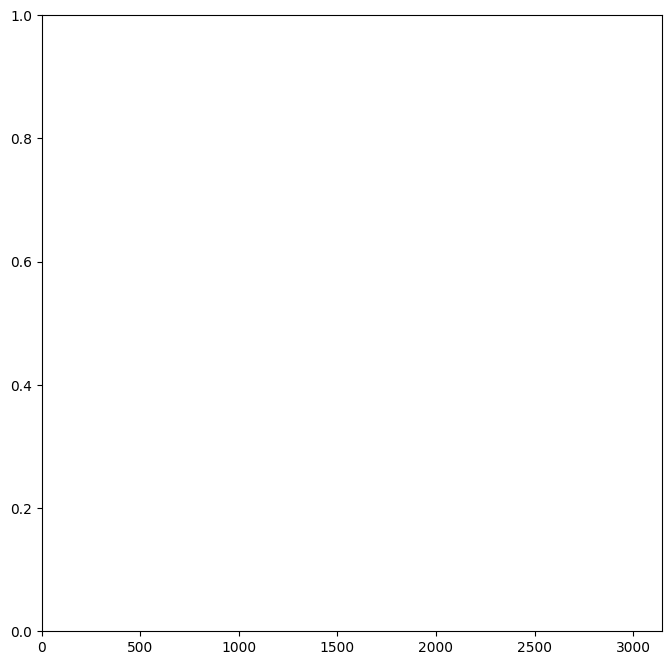

In [43]:

plt.xlim([0,len(fc[1])])
#ax=plt.axes()
#ax.set_facecolor('cyan')
plt.plot(t,fc[1])
#plt.plot(t,fc[2])
plt.plot(t,fc[3])
plt.plot(t,fc[4])
plt.plot(t,fc[7])
plt.xlim([0,len(fc[1])])
plt.grid()


In [44]:
def time_series2(Company_index,j):
    
    
#    For windowlength 100
#    y=list(fc[Company_index][200*(j-2)+200:200*(j)+199])
#For windowlength 200   
    int(j)
    y=list(fc[Company_index][100*(j-2)+100:100*(j)+99])

    log_ret  = [np.log(y[i+1])-np.log(y[i]) for i in range(len(y)-1)]
    return log_ret


In [45]:
import numpy as np
import gcmi
import csv
import itertools
import matplotlib.pyplot as plt
import random
import pandas as pd
import statistics


    
def mutual_info(x,y):
    return gcmi.gcmi_cc(x,y)

def interaction_info(x,y,z):
    return gcmi.gcmi_cc(x,y) - gcmi.gccmi_ccc(x,y,z)

# MARKET SELECTION BSE

In [46]:
CAP=['RIL IB Equity','TCS IB Equity', 'HDFC IB Equity','INFO IB Equity','HUVR IB Equity','ICICIBC IB Equity','SBIN IB Equity','ITC IB Equity','BHARTI IB Equity','BJFIN IB Equity','KMB IB Equity','HCLT IB Equity','LT IB Equity','AXSB IB Equity','MSIL IB Equity', 'SUNP IB Equity','WPRO IB Equity','TTAN IB Equity','UTCEM IB Equity','ADE IB Equity','ONGC IB Equity','NEST IB Equity','MM IB Equity','NTPC IB Equity','PWGR IB Equity','TECHM IB Equity','APNT IB Equity','JSTL IB Equity','BJAUT IB Equity','CIPLA IB Equity','DIVI IB Equity','TTMT IB Equity','DRRD IB Equity','ADSEZ IB Equity','VEDL IB Equity']

CAP_index=[]
CAP_values=[]

for i in range(len(CAP)):
    for j in range(len(Companies)):
        if CAP[i]==Companies[j]:
            CAP_index.append(j)

for i in CAP_index:
    CAP_values.append(fc[i])
#print((CAP_values[18]))    

#Pairwise network from the selected companies

P1=list(itertools.combinations(CAP_index,2))
P2=list(itertools.combinations(CAP,2))

#Higher order network from selected companies

T1=list(itertools.combinations(CAP_index,3))
T2=list(itertools.combinations(CAP,3))

print(len(T2),len(P2),len(CAP))

6545 595 35


# MODIFIED FUNCTION FOR CUTTING THE TIME SERIES

In [47]:
def time_series(Company_index,j):
    
    
#    For windowlength 100
#    y=list(fc[Company_index][200*(j-2)+200:200*(j)+199])
#For windowlength 200   
    int(j)
    y=list(fc[Company_index][0:round(len(fc[Company_index])/j)])

    log_ret  = [np.log(y[i+1])-np.log(y[i]) for i in range(len(y)-1)]
    return log_ret

# STATIC ANALYSIS

In [48]:


W=[]
w=[]
N=[]
NTH=[]
EVO=[]
EVO_TH=[]
U=[]
ADJ_P_LIST_ALL=[]
ADJ_P_LIST_ALL_TH=[]
ADJ_P_INDEX_ALL=[]
ADJ_P_INDEX_ALL_TH=[]
Community_structure=[]
Community_structure1=[]
WEIGHTMI_ALL_TH=[]
WEIGHTMI_ALL=[]
for u in tqdm(range(1,2)):
    W.append(u)
    w.append(DATE[100*u])
    ind=u
    
    
    
    
    MI_set=[]
#x,y=L2[226]
    mi=mutual_info(time_series2(21,5),time_series2(22,5))
#    print(mi)


    for i in range(len(P2)):
        x,y=P1[i]
        mi=mutual_info(time_series(x,u),time_series(y,u))
        MI_set.append(mi)



#P TEST
   
    data=[]
    with open(f'BSI100MISTATIC{u}.csv', 'r') as file:
      csvreader = csv.reader(file)
      for row in csvreader:
          data.append(row)


    print(u,len(data))
    Count=[]
    WeightMI=[]
    P_edge_index=[]
    P_edge_list=[]

    for i in range(len(MI_set)):
        count=0
        for j in range(len(data[i])):
            u=str(MI_set[i])
            v=str(data[i][j])
            if  u<v:
                count=count+1
        Count.append(count/100)
#print(len(Count))
#print(len(P))

    count2=0
    for o in range(len(Count)):
        int(Count[o])
        if Count[o]<0.1:
            count2=count2+1
            WeightMI.append(MI_set[o])
            P_edge_list.append(P2[o])
            P_edge_index.append(P1[o])
        
    N.append(count2)
    WEIGHTMI_ALL.append(WeightMI)
    ADJ_P_LIST_ALL.append(P_edge_list)
    ADJ_P_INDEX_ALL.append(P_edge_index)

    
    
    temp_degree=[]
    for i in P_edge_list:
        a,b=i
        temp_degree.append(a)
        temp_degree.append(b)
    d_dist=[]
    for i in CAP:
        d_dist.append(temp_degree.count(i))
    
    EVO.append(d_dist)
    
    
    U.append(sum(WeightMI)/(2*26))
    
    meanP=sum(WeightMI)/len(WeightMI)
    stdevP=statistics.stdev(WeightMI)
    AdjP_index=[]
    AdjP_list=[]
    Final_weightlistMI=[]
    for i in range(len(WeightMI)):
        if WeightMI[i]>meanP+0.0*stdevP:
            AdjP_index.append(P_edge_index[i])
            AdjP_list.append(P_edge_list[i])
            Final_weightlistMI.append(WeightMI[i])

    NTH.append(len(AdjP_index))
    WEIGHTMI_ALL_TH.append(Final_weightlistMI)
    ADJ_P_LIST_ALL_TH.append(AdjP_list)
    ADJ_P_INDEX_ALL_TH.append(AdjP_index)
    
    



    
    temp_degree=[]
    for i in AdjP_list:
        a,b=i
        temp_degree.append(a)
        temp_degree.append(b)
    d_dist=[]
    for i in CAP:
        d_dist.append(temp_degree.count(i))
    EVO_TH.append(d_dist)

100%|█████████████████████████████████████████████| 1/1 [00:03<00:00,  3.31s/it]

1 595


In [49]:
len(ADJ_P_LIST_ALL[0])

365

# Converting to matrix

In [50]:
edges = ADJ_P_LIST_ALL[0]
node_list=CAP




def edge_list_to_adjacency_matrix_and_save(
    edge_list,
    node_list,
    filename,
    directed=False,
    save_index_map=True
):
    """
    Convert edge list to adjacency matrix (ordered by node_list)
    and save it to a text file.

    Parameters:
        edge_list (list of tuples): [('u','v'), ...]
        node_list (list): desired node order
        filename (str): output .txt file name
        directed (bool): directed or undirected graph
        save_index_map (bool): save node-index mapping in file
    """

    n = len(node_list)
    index_map = {node: i for i, node in enumerate(node_list)}

    A = np.zeros((n, n), dtype=int)

    for u, v in edge_list:
        if u not in index_map or v not in index_map:
            continue

        i, j = index_map[u], index_map[v]
        A[i, j] = 1
        if not directed:
            A[j, i] = 1

    # -------- SAVE TO FILE --------
    with open(filename, "w") as f:
        if save_index_map:
            f.write("# Node index mapping\n")
            for node, idx in index_map.items():
                f.write(f"# {idx}: {node}\n")
            f.write("\n# Adjacency Matrix\n")

        np.savetxt(f, A, fmt="%d")

    return A


In [51]:
A = edge_list_to_adjacency_matrix_and_save(
    edges,
    node_list,
    filename="Adjacency_matrix_static.txt",
    directed=False
)


In [52]:
with open("node_list.txt", "w") as f:
    for node in node_list:
        f.write(f"{node}\n")

In [53]:
G=nx.Graph()
G.add_edges_from(ADJ_P_LIST_ALL_TH[0])
Community=nx.community.louvain_communities(G)
m = nx.community.modularity(G,Community)
print(len(ADJ_P_LIST_ALL_TH[0]),m)

124 0.26326742976066597


In [54]:

# Step 1: Convert to dictionary
community_dict = {f"Community-{i+1}": list(comm) 
                  for i, comm in enumerate(Community)}

print(community_dict)


{'Community-1': ['UTCEM IB Equity', 'LT IB Equity', 'KMB IB Equity', 'RIL IB Equity', 'HDFC IB Equity', 'APNT IB Equity', 'BJAUT IB Equity', 'AXSB IB Equity'], 'Community-2': ['ONGC IB Equity', 'TTMT IB Equity', 'ADE IB Equity', 'NTPC IB Equity', 'VEDL IB Equity', 'ADSEZ IB Equity', 'PWGR IB Equity'], 'Community-3': ['WPRO IB Equity', 'TECHM IB Equity', 'INFO IB Equity', 'TCS IB Equity', 'HCLT IB Equity'], 'Community-4': ['ICICIBC IB Equity', 'NEST IB Equity', 'BJFIN IB Equity', 'JSTL IB Equity', 'MSIL IB Equity', 'HUVR IB Equity', 'ITC IB Equity', 'BHARTI IB Equity', 'SBIN IB Equity', 'TTAN IB Equity', 'MM IB Equity'], 'Community-5': ['DIVI IB Equity', 'CIPLA IB Equity', 'DRRD IB Equity', 'SUNP IB Equity']}


In [55]:
with open("Communities_static.txt", "w") as f:
    for key, nodes in community_dict.items():
        # join nodes with commas
        node_str = ", ".join(nodes)
        f.write(f"{key}: {node_str}\n")


In [56]:
communities = list(greedy_modularity_communities(G))

# Map node -> community id
node_to_comm = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_comm[node] = i


NameError: name 'greedy_modularity_communities' is not defined

In [35]:
pos = {}

# distance between community clusters
offset = 3.0  

for i, comm in enumerate(communities):
    subgraph = G.subgraph(comm)

    # layout inside each community
    sub_pos = nx.spring_layout(
    subgraph,
    k=1.8,       # 👈 increase this for more spacing
    iterations=50,
    seed=42
)

    # shift each community to its own location
    shift_x = (i % 3) * offset
    shift_y = (i // 3) * offset

    for node, (x, y) in sub_pos.items():
        pos[node] = (x + shift_x, y + shift_y)


NameError: name 'communities' is not defined

In [36]:
degrees = dict(G.degree())
node_sizes = [degrees[n] * 300 for n in G.nodes()]


In [37]:


group_dict = {
    1: ['RIL IB Equity', 'ONGC IB Equity'],
    2: ['TCS IB Equity','INFO IB Equity','HCLT IB Equity','WPRO IB Equity','TECHM IB Equity'],
    3: ['HDFC IB Equity','ICICIBC IB Equity','SBIN IB Equity','BJFIN IB Equity','AXSB IB Equity'],
    4: ['HUVR IB Equity','SUNP IB Equity','CIPLA IB Equity'],
    5: ['ITC IB Equity','NEST IB Equity'],
    6: ['BHARTI IB Equity'],
    7: ['KMB IB Equity','LT IB Equity','ADE IB Equity','PWGR IB Equity','APNT IB Equity','ADSEZ IB Equity'],
    8: ['MSIL IB Equity','BJAUT IB Equity','TTMT IB Equity'],
    9: ['TTAN IB Equity','UTCEM IB Equity','MM IB Equity','JSTL IB Equity','DRRD IB Equity','VEDL IB Equity'],
    10: ['DIVI IB Equity'],
    11: ['NTPC IB Equity']
}

In [38]:
# Build node -> group map
node_to_group = {}
for group, nodes in group_dict.items():
    for node in nodes:
        node_to_group[node] = group

groups = [node_to_group.get(n, -1) for n in G.nodes()]
unique_groups = sorted(set(g for g in groups if g != -1))

cmap = cm.get_cmap("tab10", len(unique_groups))

node_colors = [
    cmap(unique_groups.index(g)) if g != -1 else "lightgray"
    for g in groups
]


NameError: name 'cm' is not defined

In [39]:
plt.figure(figsize=(12, 10))

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors="black",
    alpha=0.9
)

nx.draw_networkx_edges(G, pos, width=1.2, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=9)

plt.axis("off")
plt.tight_layout()
plt.show()


NameError: name 'node_colors' is not defined

<Figure size 1200x1000 with 0 Axes>

/var/folders/z_/lxkyxgq53_54hftk7vv3kdg80000gn/T/ipykernel_49635/1847972890.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("tab10", len(unique_groups))


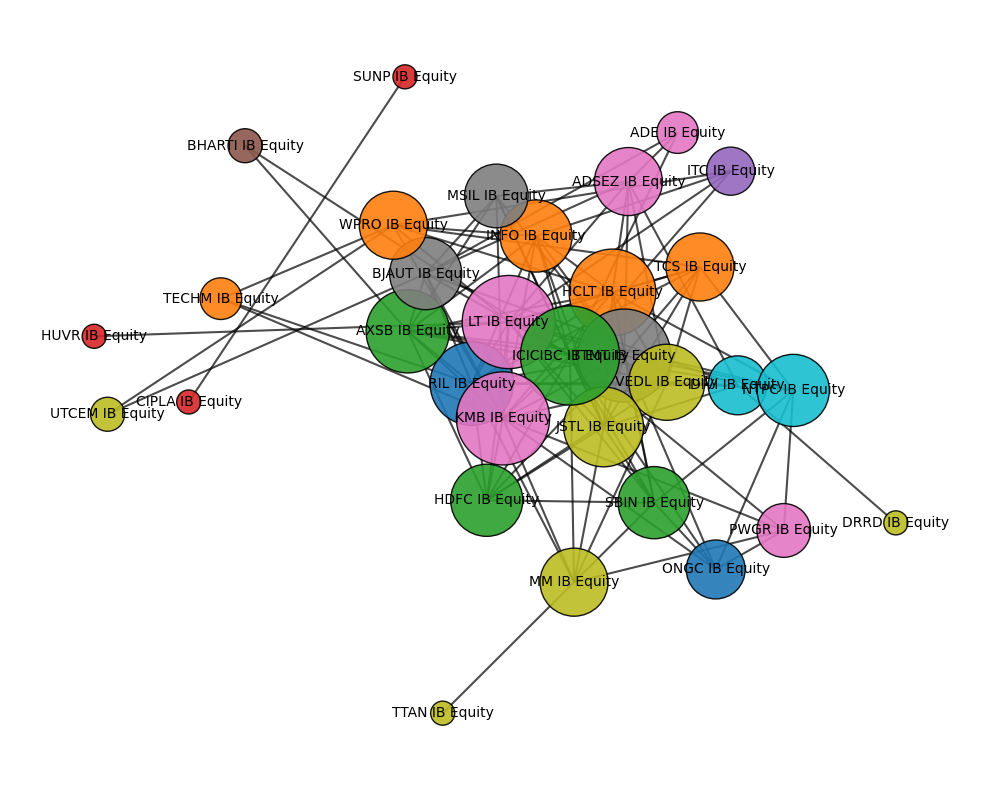

In [78]:


# Layout with good separation
pos = nx.spring_layout(G, k=1.0, seed=42)

# Node size proportional to degree
degrees = dict(G.degree())
node_sizes = [degrees[n] * 300 for n in G.nodes()]

# --------- BUILD NODE → GROUP MAP ----------
node_to_group = {}
for group, nodes in group_dict.items():
    for node in nodes:
        node_to_group[node] = group

# Get group for each node (default -1 if missing)
groups = [node_to_group.get(n, -1) for n in G.nodes()]

# Color map (one color per group)
unique_groups = sorted(set(g for g in groups if g != -1))
cmap = cm.get_cmap("tab10", len(unique_groups))

node_colors = [
    cmap(unique_groups.index(g)) if g != -1 else "lightgray"
    for g in groups
]

# --------- DRAW ----------
plt.figure(figsize=(10, 8))

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors="black",
    alpha=0.9
)

nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.axis("off")
plt.tight_layout()
plt.show()


# DYNAMICAL ANALYSIS

In [12]:
W=[]
w=[]
N=[]
NTH=[]
EVO=[]
EVO_TH=[]
U=[]
ADJ_P_LIST_ALL=[]
ADJ_P_LIST_ALL_TH=[]
ADJ_P_INDEX_ALL=[]
ADJ_P_INDEX_ALL_TH=[]
Community_structure=[]
Community_structure1=[]
WEIGHTMI_ALL_TH=[]
WEIGHTMI_ALL=[]
for u in tqdm(range(1,31)):
    W.append(u)
    w.append(DATE[100*u])
    ind=u
    
    
    
    
    MI_set=[]
#x,y=L2[226]
    mi=mutual_info(time_series2(21,5),time_series2(22,5))
#    print(mi)


    for i in range(len(P2)):
        x,y=P1[i]
        mi=mutual_info(time_series2(x,u),time_series2(y,u))
        MI_set.append(mi)



#P TEST
   
    data=[]
    with open(f'BSI100MI100{u}.csv', 'r') as file:
      csvreader = csv.reader(file)
      for row in csvreader:
          data.append(row)


    print(u,len(data))
    Count=[]
    WeightMI=[]
    P_edge_index=[]
    P_edge_list=[]

    for i in range(len(MI_set)):
        count=0
        for j in range(len(data[i])):
            u=str(MI_set[i])
            v=str(data[i][j])
            if  u<v:
                count=count+1
        Count.append(count/100)
#print(len(Count))
#print(len(P))

    count2=0
    for o in range(len(Count)):
        int(Count[o])
        if Count[o]<0.05:
            count2=count2+1
            WeightMI.append(MI_set[o])
            P_edge_list.append(P2[o])
            P_edge_index.append(P1[o])
        
    N.append(count2)
    WEIGHTMI_ALL.append(WeightMI)
    ADJ_P_LIST_ALL.append(P_edge_list)
    ADJ_P_INDEX_ALL.append(P_edge_index)

    
    
    temp_degree=[]
    for i in P_edge_list:
        a,b=i
        temp_degree.append(a)
        temp_degree.append(b)
    d_dist=[]
    for i in CAP:
        d_dist.append(temp_degree.count(i))
    
    EVO.append(d_dist)
    
    
    U.append(sum(WeightMI)/(2*26))
    
    meanP=sum(WeightMI)/len(WeightMI)
    stdevP=statistics.stdev(WeightMI)
    AdjP_index=[]
    AdjP_list=[]
    Final_weightlistMI=[]
    for i in range(len(WeightMI)):
        if WeightMI[i]>meanP+0.0*stdevP:
            AdjP_index.append(P_edge_index[i])
            AdjP_list.append(P_edge_list[i])
            Final_weightlistMI.append(WeightMI[i])

    NTH.append(len(AdjP_index))
    WEIGHTMI_ALL_TH.append(Final_weightlistMI)
    ADJ_P_LIST_ALL_TH.append(AdjP_list)
    ADJ_P_INDEX_ALL_TH.append(AdjP_index)
    
    



    
    temp_degree=[]
    for i in AdjP_list:
        a,b=i
        temp_degree.append(a)
        temp_degree.append(b)
    d_dist=[]
    for i in CAP:
        d_dist.append(temp_degree.count(i))
    EVO_TH.append(d_dist)

  3%|█▍                                          | 1/30 [00:00<00:07,  3.72it/s]

1 595


  7%|██▉                                         | 2/30 [00:00<00:07,  3.81it/s]

2 595


 10%|████▍                                       | 3/30 [00:00<00:07,  3.85it/s]

...

28 595


 97%|█████████████████████████████████████████▌ | 29/30 [00:07<00:00,  3.86it/s]

29 595


100%|███████████████████████████████████████████| 30/30 [00:07<00:00,  3.83it/s]

30 595


In [19]:
for I in range(30):
    f = open(f'ADJP_LIST_WINDOW{I}.dat', 'w')
    for i in range(len(ADJ_P_LIST_ALL[I])):
        print( ADJ_P_LIST_ALL[I][i], file=f)
    f.close()

In [20]:
for I in range(30):
    f = open(f'ADJP_INDEX_WINDOW{I}.dat', 'w')
    for i in range(len(ADJ_P_INDEX_ALL[I])):
        print( ADJ_P_INDEX_ALL[I][i], file=f)
    f.close()

In [15]:
CommunitiesP_all=[]
GraphP_list=[]
for i in range(30):
    G=nx.from_edgelist(ADJ_P_INDEX_ALL[i])
    GraphP_list.append(G)
    CommunitiesP_all.append(nx.community.louvain_communities(G))

In [16]:
for i in range(len(CommunitiesP_all)):
    print(i,len(CommunitiesP_all[i]),GraphP_list[i].number_of_edges(),GraphP_list[i].number_of_nodes())

0 3 450 35
1 2 569 35
2 2 566 35
3 2 531 35
4 2 520 35
5 3 414 35
6 3 362 35
7 2 385 35
8 2 456 35
9 2 418 35
10 2 302 35
11 3 353 35
12 2 474 35
13 3 511 35
14 2 531 35
15 2 521 35
16 3 475 35
17 3 406 35
18 3 299 35
19 4 332 35
20 3 372 35
21 3 402 35
22 2 418 35
23 3 426 35
24 3 404 35
25 1 590 35
26 1 593 35
27 2 508 35
28 2 519 35
29 3 435 35


In [17]:
MembershipP_all=[]
for i in range(len(CommunitiesP_all)):
    MembershipP=[0 for m in range(len(CAP))]
    for j in range(len(CommunitiesP_all[i])):
        a=list(CommunitiesP_all[i][j])
        for k in range(len(a)):
            MembershipP[CAP_index.index(a[k])]=j
    MembershipP_all.append(MembershipP)

In [18]:
PH_RAND=[]
PH_MI=[]
PT_RAND=[]
PT_MI=[]
HT_RAND=[]
HT_MI=[]
t=[]
for i in range(30):
    t.append(i)
    
    HT_RAND.append(adjusted_rand_score(Membership_all[i], sector_indices))
    
    HT_MI.append(adjusted_mutual_info_score(Membership_all[i], sector_indices))
    
    HT_RAND.append(adjusted_rand_score(MembershipP_all[i], sector_indices))
    
    HT_MI.append(adjusted_mutual_info_score(MembershipP_all[i], sector_indices))
    
    PH_RAND.append(adjusted_rand_score(Membership_all[i], MembershipP_all[i]))
    
    HT_MI.append(adjusted_mutual_info_score(Membership_all[i], sector_indices))
    

NameError: name 'adjusted_rand_score' is not defined

In [9]:
for I in range(30):
    f = open(f'ADJH_INDEX_WINDOW{I}.dat', 'w')
    for i in range(len(ADJH_INDEX_ALL[I])):
        print( ADJH_INDEX_ALL[I][i], file=f)
    f.close()

NameError: name 'ADJH_INDEX_ALL' is not defined

In [ ]:
for I in range(30):
    f = open(f'ADJH_LIST_WINDOW{I}.dat', 'w')
    for i in range(len(ADJH_LIST_ALL[I])):
        print( ADJH_LIST_ALL[I][i], file=f)
    f.close()

# WRITING INDIVIDUAL DEGREE OF EACH COMPANY TO FILE

In [ ]:
for i in range(30):
    for j in range(26)
    

In [10]:
import csv
import statistics
import matplotlib.pyplot as plt
N3=[]
N3TH=[]
W=[]
EVO3=[]
EVO3_TH=[]
U1=[]
ADJH_LIST_ALL=[]
ADJH_LIST_ALL_TH=[]
ADJH_INDEX_ALL=[]
ADJH_INDEX_ALL_TH=[]
WEIGHTII_ALL=[]
WEIGHTII_ALL_TH=[]
for u in tqdm(range(1,31)):
    W.append(u)
    ind=u
    II_set=[]
#x,y=L2[226]
    ii=interaction_info(time_series2(1,5),time_series2(2,5),time_series2(3,5))
#    print(ii)


    for i in range(len(T1)):
        x,y,z=T1[i]
        ii=interaction_info(time_series2(x,u),time_series2(y,u),time_series2(z,u))
        II_set.append(ii)
 

#Writing the interaction information value into a column in a csv file

    with open(f'REAL_VALUE_BSE_CAP{u}.csv', 'w') as fi:
        writer = csv.writer(fi)
        for val in II_set:
            writer.writerow([val])

#    print(len(T2),len(II_set))



#FINDING NUMBER OF SYNERGISTIC EDGES

    Synergic_edge_list=[]
    Synergic_edge_index=[]
    Synergic_edge_value=[]
    for i in range(len(II_set)):
        v1=float(II_set[i])
        if v1<0:
            Synergic_edge_list.append(T2[i])
            Synergic_edge_index.append(T1[i])
            Synergic_edge_value.append(v1)
    print("NO OF POSSIBLE H INTERACTIONS-",len(Synergic_edge_index))
    
    
    
    

    if len(Synergic_edge_index)==0:
        N3.append(0)
        N3TH.append(0)
        EVO3.append(0)
        EVO3_TH.append(0)
        ADJH_LIST_ALL.append(0)
        ADJH_LIST_ALL_TH.append(0)
        ADJH_INDEX_ALL.append(0)
        ADJH_INDEX_ALL_TH.append(0)
        WEIGHTII_ALL.append(0)
        WEIGHTII_ALL_TH.append(0)
        continue


    #SHUFFLING

    j=u
#for j in range(3,15):
    II_total=[]

    for i in Synergic_edge_index:
        a,b,c=i
        II_inter=[]
        y=time_series2(b,j)
        x=time_series2(a,j)
        z=time_series2(c,j)

        for k in range(100):
            random.shuffle(x)
            random.shuffle(y)
            random.shuffle(z)
            ii=interaction_info(x,y,z)
            II_inter.append(ii)
        II_total.append(II_inter)
        with open(f'BSI100II_CAP{j}.csv', 'w', encoding='UTF8', newline='') as fpi:
            writer = csv.writer(fpi,delimiter = ',')
            writer.writerows(II_total)
        
    
    data=[]
    with open(f"BSI100II_CAP{u}.csv", 'r') as file:
      csvreader = csv.reader(file)
      for row in csvreader:
          data.append(row)

    

    Count=[]
    WeightII=[]
    H_edge_index=[]
    H_edge_list=[]
    for i in range(len(Synergic_edge_value)):
        count=0
        for j in range(100):
            u2=float(Synergic_edge_value[i])
            v2=float(data[i][j])
            if  u2>v2:
                count=count+1
        Count.append(count/100)
#    print(sum(Count)/len(Count))

    count2=0
    for o in range(len(Count)):
    
        if Count[o]<0.05:
            count2=count2+1
            WeightII.append(Synergic_edge_value[o])
            H_edge_index.append(Synergic_edge_index[o])
            H_edge_list.append(Synergic_edge_list[o])
    
    N3.append(count2)
    WEIGHTII_ALL.append(WeightII)
    ADJH_LIST_ALL.append(H_edge_list)
    ADJH_INDEX_ALL.append(H_edge_index)
    U1.append(sum(WeightII)/(3*26))    
    
    
    temp_degree=[]
    for i in H_edge_list:
        a,b,c=i
        temp_degree.append(a)
        temp_degree.append(b)
        temp_degree.append(c)
    d_dist=[]
    for i in CAP:
        d_dist.append(temp_degree.count(i))
    
    EVO3.append(d_dist)
        
    
    if len(WeightII)==0:
        N3TH.append(0)
        EVO3_TH.append(0)
#        ADJH_LIST_ALL.append(0)
        ADJH_LIST_ALL_TH.append(0)
#        ADJH_INDEX_ALL.append(0)
        ADJH_INDEX_ALL_TH.append(0)
        WEIGHTII_ALL.append(0)
        WEIGHTII_ALL_TH.append(0)
        continue
    
    print("STATISTICALLY VALID H INTERACTIONS-",len(WeightII))
    mean=sum(WeightII)/len(WeightII)
#    stdev=statistics.stdev(WeightII)
    AdjH_index=[]
    AdjH_list=[]
    Final_weightlistII=[]
    for i in range(len(WeightII)):
        if WeightII[i]<mean:
            AdjH_index.append(H_edge_index[i])
            AdjH_list.append(H_edge_list[i])
            Final_weightlistII.append(WeightII[i])
    N3TH.append(len(AdjH_index))
    WEIGHTII_ALL_TH.append(Final_weightlistII)
    ADJH_LIST_ALL_TH.append(AdjH_list)
    ADJH_INDEX_ALL_TH.append(AdjH_index)
    
    H = hnx.Hypergraph(AdjH_list)






#hnx.drawing.rubber_band.draw(H,pos = layout)
#plt.show()
    No_nodes = len(list(H.nodes))
    No_hypedges = len(list(H.edges))
    pos = hnx.drawing.rubber_band.layout_node_link(H,layout=nx.kamada_kawai_layout,scale=10)
    G = H.bipartite()
    nx.write_gexf(G, f'II_Hypergraph_BSI100_w{ind}.gexf')
    
    
    
    
    
    temp_degree=[]
    for i in AdjH_list:
        a,b,c=i
        temp_degree.append(a)
        temp_degree.append(b)
        temp_degree.append(c)
    d_dist=[]
    for i in CAP:
        d_dist.append(temp_degree.count(i))
    
    EVO3_TH.append(d_dist)

  0%|                                                    | 0/30 [00:00<?, ?it/s]

NO OF POSSIBLE H INTERACTIONS- 125


  3%|█▍                                          | 1/30 [00:05<02:50,  5.89s/it]

STATISTICALLY VALID H INTERACTIONS- 83


  7%|██▉                                         | 2/30 [00:07<01:34,  3.39s/it]

...

STATISTICALLY VALID H INTERACTIONS- 32
NO OF POSSIBLE H INTERACTIONS- 63


 97%|█████████████████████████████████████████▌ | 29/30 [06:11<00:06,  6.30s/it]

STATISTICALLY VALID H INTERACTIONS- 43
NO OF POSSIBLE H INTERACTIONS- 43


100%|███████████████████████████████████████████| 30/30 [06:14<00:00, 12.49s/it]

STATISTICALLY VALID H INTERACTIONS- 36


In [11]:
for i in range(30):
    if ADJH_LIST_ALL[i]==0:
        ADJH_LIST_ALL[i]=[]
        ADJH_INDEX_ALL[i]=[]
        WEIGHTII_ALL[i]=[]
        WEIGHTII_ALL_TH[i]=[]

for i in range(30):
    if ADJH_INDEX_ALL_TH[i]==0:
#        ADJH_LIST_ALL_TH[i]=[]
        ADJH_INDEX_ALL_TH[i]=[]
        WEIGHTII_ALL_TH[i]=[]

In [78]:
len(N_listP)

30

# NO.1-VECTOR CENTRALITY

In [12]:
EIGEN_VECTOR_ALL=[]
for i in range(30):
    G2=nx.from_edgelist(ADJ_P_INDEX_ALL[i],create_using=nx.Graph)
    Pairwise_centrality=nx.eigenvector_centrality(G2)
    Pairwise_eigenvector_norm=[]
    NORMP=0
    for i in Pairwise_centrality.values():
        Pairwise_eigenvector_norm.append(i)
        NORMP=NORMP+i
    print(NORMP)
    for i in range(len(Pairwise_eigenvector_norm)):
        Pairwise_eigenvector_norm[i]=Pairwise_eigenvector_norm[i]/NORMP
    EIGEN_VECTOR_ALL.append(Pairwise_eigenvector_norm)

5.021018499480635
5.0888099540711424
5.090279812284501
4.996687348037848
5.066592935083678
4.97265373526166
4.877075862486474
4.7442840564193345
4.866750621052746
4.747553213896645
4.476449662383154
4.601183296259951
5.008406039607932
5.031591107619374
5.066843520996804
5.047168213798476
4.969638359163191
4.849403836586306
4.6048228933455135
4.7144550994253
4.7619078728122775
4.727033706438288
4.808753324085377
4.887043765417588
4.728621671683773
5.098768401276595
5.098768401276595
5.043728735196534
5.074903364133461
4.970122116689736


In [13]:
VECTOR_CENTRALITY_ALL=[]

#MAIN LOOP FOR WINDOWS
for i in range(30):
    Line_index=[]
    Line_edges_index=[]
    Line_edges_name=[]
    Line_symbolic=[]
    if len(ADJH_LIST_ALL[i])==0:
        VECTOR_CENTRALITY_ALL.append(0)
        continue
#SUBLOOP 1 FOR CONVERTING HYPERGRAPH INTO LINE GRAPH
    for i1 in tqdm(range(len(ADJH_LIST_ALL[i]))):
        Line_index.append(i1)
        a1,b1,c1=ADJH_LIST_ALL[i][i1]
        a2,b2,c2=ADJH_INDEX_ALL[i][i1]
        for j in range(len(ADJH_LIST_ALL[i])):
            d1,e1,f1=ADJH_LIST_ALL[i][j]
            d2,e2,f2=ADJH_INDEX_ALL[i][j]
            if a2+b2+c2==d2+e2+f2 and pow(a2,2)+pow(b2,2)+pow(c2,2)==pow(d2,2)+pow(e2,2)+pow(f2,2):
                break
            if a2==d2 or a2==e2 or a2==f2 or b2==d2 or b2==e2 or b2==f2 or c2==d2 or c2==e2 or c2==f2:
                Line_edges_index.append(((a2,b2,c2),(d2,e2,f2)))
                Line_edges_name.append(((a1,b1,c1),(d1,e1,f1)))
                Line_symbolic.append((i1,j))
    print("LINE GRAPH LENGTH=",len(Line_symbolic))
    if len(Line_symbolic)==0:
        VECTOR_CENTRALITY_ALL.append(0)
        continue
#CONVERSION OF ADJ LIST INTO GRAPH AND CALCULATING THE EIGEN VECTORS
    G1=nx.from_edgelist(Line_symbolic,create_using=nx.Graph)
    Line_centrality=nx.eigenvector_centrality(G1)
    EC=Line_centrality.values()
    NORM=0
    Line_eigenvector_norm=[]
    for i3 in EC:
        Line_eigenvector_norm.append(i3)
        NORM=NORM+i3
    print("TOTAL EIGEN CENTRALITY VALUE",NORM)
    for i2 in range(len(Line_eigenvector_norm)):
        Line_eigenvector_norm[i2]=Line_eigenvector_norm[i2]/NORM
    Vector_centrality=[]
    for i3 in CAP_index:
        VC_inter=0
        for j1 in range(len(ADJH_INDEX_ALL[i])):
            a,b,c=ADJH_INDEX_ALL[i][j1]
            if a==i3 or b==i3 or c==i3:
                VC_inter=VC_inter+Line_eigenvector_norm[j1]
        Vector_centrality.append(VC_inter/3)
    VECTOR_CENTRALITY_ALL.append(Vector_centrality)
    print("INDEX RUNNING",i)

100%|████████████████████████████████████████| 83/83 [00:00<00:00, 28591.26it/s]


LINE GRAPH LENGTH= 2017
TOTAL EIGEN CENTRALITY VALUE 8.606494512306169
INDEX RUNNING 0


100%|██████████████████████████████████████████| 1/1 [00:00<00:00, 41527.76it/s]


LINE GRAPH LENGTH= 0


100%|████████████████████████████████████████| 60/60 [00:00<00:00, 38812.19it/s]


...

LINE GRAPH LENGTH= 192
TOTAL EIGEN CENTRALITY VALUE 4.84484126564677
INDEX RUNNING 27


100%|████████████████████████████████████████| 43/43 [00:00<00:00, 65133.65it/s]


LINE GRAPH LENGTH= 551
TOTAL EIGEN CENTRALITY VALUE 6.361011301235591
INDEX RUNNING 28


100%|████████████████████████████████████████| 36/36 [00:00<00:00, 90200.09it/s]

LINE GRAPH LENGTH= 339
TOTAL EIGEN CENTRALITY VALUE 5.219661457529156
INDEX RUNNING 29


In [14]:
for i in range(len(VECTOR_CENTRALITY_ALL)):
    print(VECTOR_CENTRALITY_ALL[i])
    if VECTOR_CENTRALITY_ALL[i]==0:
        VECTOR_CENTRALITY_ALL[i]=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
        print("u")

[0.020509876293507003, 0.014737359388708002, 0.012609948357403067, 0.013618676310757182, 0.007849070147092366, 0.023299401565484112, 0.014766989119632949, 0.020509876293507003, 0.014850983975026986, 0.009878265002267362, 0.011488257694161947, 0.021532968670948064, 0.005294149525860895, 0.02278981669282112, 0.023299401565484112, 0.038989889784747954, 0.06197226860268839, 0.02190821503354205, 0.1299993788634804, 0.24399357601928218, 0.013443589155158019, 0.11057853166118564, 0.09468245567343042, 0.020509876293506996, 0.013443589155158019, 0.013443589155158019]
0
u
0
u
[0.051611010074153925, 0.021565172419286276, 0.014529530076115104, 0.006892162404628453, 0.0, 0.030354325379451253, 0.049740365059615606, 0.04975135289348539, 0.02059880624054017, 0.0004705012427157366, 0.01372919989005252, 0.02157398405671963, 0.02861846459398272, 0.021642952333179585, 0.10645661729906507, 0.02061109960021187, 0.02182018349881121, 0.02059880624054017, 0.014666884065997443, 0.04115585774748084, 0.0215865600

# NO-2 VON NEUMANN ENTROPY

In [15]:
ADJMP_ALL=[]
u1=0
u2=0
for i in range(len(ADJ_P_LIST_ALL)):
    ADJMP=[]
    for i1 in range(26):
        adj=[]
        for j1 in range(26):
            adj.append(0)
        ADJMP.append(adj)
    c=0
    for j in range(len(ADJ_P_LIST_ALL[i])):
        a,b=ADJ_P_LIST_ALL[i][j]
        ADJMP[CAP.index(a)][CAP.index(b)]=-1
        ADJMP[CAP.index(b)][CAP.index(a)]=-1
        c=len(ADJ_P_LIST_ALL[i])
    print(c)
        
        
        
    ADJMP_ALL.append(ADJMP)
    
#WE HAVE 30 26*26 MATRICES WHICH WE'LL BEUSING IN THE NEXT CODE BLOCK TO CONSTRUCT THE LAPLACIANS AND THEN PROCEEEDING FURTHER

263
311
313
287
298
247
206
205
244
228
170
185
250
275
294
291
251
214
156
173
198
209
223
236
214
324
324
269
294
245


In [16]:
LAPLACIAN_ALL=[]
for i in range(len(ADJ_P_LIST_ALL)):
    temp=[]
    D=[]
    for j in range(len(ADJ_P_LIST_ALL[i])):
        a,b=ADJ_P_LIST_ALL[i][j]
        temp.append(a)
        temp.append(b)
    for k in CAP:
        D.append(temp.count(k))
    for l  in range(26):
        ADJMP_ALL[i][l][l]=D[l]
LAPLACIAN_ALL=ADJMP_ALL  

In [17]:
EIGM=[]
EIGVM=[]
for i in range(len(ADJ_P_LIST_ALL)):
    EIG,EIGV=np.linalg.eig(LAPLACIAN_ALL[i])
    EIGM.append(EIG)
    EIGVM.append(EIGV)

In [18]:
VNE=[]
for i in range(len(EIGM)):
    vne=0
    S=sum(np.real(EIGM[i]))
    for j in range(len(EIGM[i])):
        a=np.real(EIGM[i][j])
        a=a/S
        if a<0.0001:
            b=0
        else:
            b=np.log(a)
        vne=vne+(a*b)
        
    VNE.append(-vne)
print(VNE)

[3.19235512128729, 3.2155258412609746, 3.2159689373783324, 3.181457477601171, 3.2089412784797102, 3.184759550687377, 3.154037403327553, 3.1271826702370507, 3.1598188579882, 3.139649088137932, 3.110360578586938, 3.1290891491068242, 3.1902786935821448, 3.200181604077252, 3.2086085042158303, 3.2024371198892276, 3.1842618686551094, 3.154895744485049, 3.099887471825002, 3.1219239273850508, 3.1384533210966574, 3.1310830215761047, 3.150214187909999, 3.169956976788194, 3.1291531014669856, 3.218758703059441, 3.2187587030594407, 3.202296132950051, 3.211172066869219, 3.1823177242729477]


Text(0, 0.5, 'PVNE')

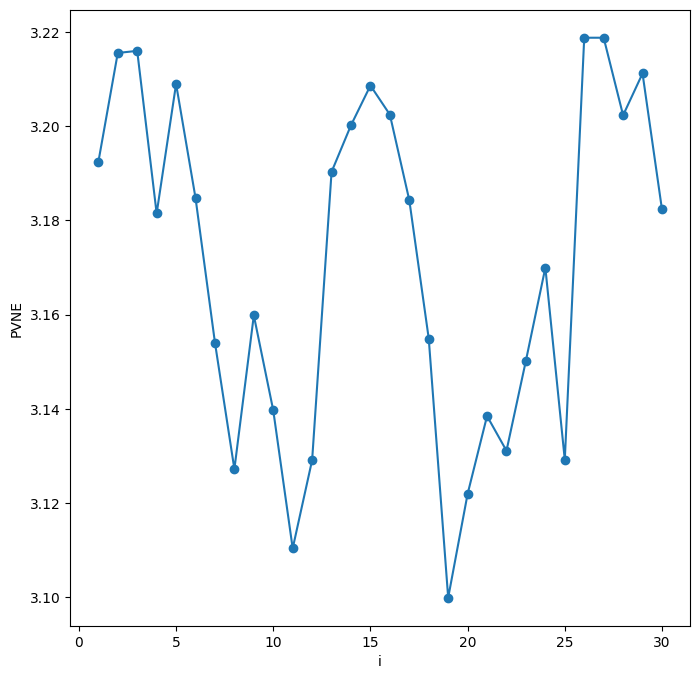

In [19]:
u=[]
for i in range(1,31):
    u.append(i)
plt.plot(u,VNE)
plt.scatter(u,VNE)

plt.xlabel("i")
plt.ylabel("PVNE")

In [20]:
import csv
import statistics
import matplotlib.pyplot as plt

ADJH_LIST_ALL=[]
ADJH_LIST_ALL_TH=[]
for u in range(1,31):
    W.append(u)
    ind=u
    II_set=[]



    for i in range(len(T1)):
        x,y,z=T1[i]
        ii=interaction_info(time_series2(x,u),time_series2(y,u),time_series2(z,u))
        II_set.append(ii)
 





#FINDING NUMBER OF SYNERGISTIC EDGES

    Synergic_edge_list=[]
    Synergic_edge_index=[]
    Synergic_edge_value=[]
    for i in range(len(II_set)):
        v1=float(II_set[i])
        if v1<0:
            Synergic_edge_list.append(T2[i])
            Synergic_edge_index.append(T1[i])
            Synergic_edge_value.append(v1)
    
    
    
    
    

    if len(Synergic_edge_index)==0:
       
        ADJH_LIST_ALL.append(0)
        ADJH_LIST_ALL_TH.append(0)
        continue


#SHUFFLING

    j=u
#for j in range(3,15):
    II_total=[]

    for i in Synergic_edge_index:
        a,b,c=i
        II_inter=[]
        y=time_series2(b,j)
        x=time_series2(a,j)
        z=time_series2(c,j)

        for k in range(100):
            random.shuffle(x)
            random.shuffle(y)
            random.shuffle(z)
            ii=interaction_info(x,y,z)
            II_inter.append(ii)
        II_total.append(II_inter)
        with open(f'BSI100II_CAP{j}.csv', 'w', encoding='UTF8', newline='') as fpi:
            writer = csv.writer(fpi,delimiter = ',')
            writer.writerows(II_total)
        
    
    data=[]
    with open(f"BSI100II_CAP{u}.csv", 'r') as file:
      csvreader = csv.reader(file)
      for row in csvreader:
          data.append(row)

    

    Count=[]
    WeightII=[]
    H_edge_index=[]
    H_edge_list=[]
    for i in range(len(Synergic_edge_value)):
        count=0
        for j in range(100):
            u2=float(Synergic_edge_value[i])
            v2=float(data[i][j])
            if  u2>v2:
                count=count+1
        Count.append(count/100)
    

    count2=0
    for o in range(len(Count)):
    
        if Count[o]<0.05:
            count2=count2+1
           
            H_edge_list.append(Synergic_edge_list[o])
    
    
    ADJH_LIST_ALL.append(H_edge_list)
    print(len(Synergic_edge_index),len(H_edge_list))
       
    
    
    

125 84
1 0
1 1
101 60
10 7
88 63
399 210
414 208
302 208
455 314
872 447
833 468
158 99
65 33
4 4
50 47
123 70
317 182
601 257
377 131
423 242
452 265
292 188
163 107
503 285
45 28
63 45
43 35


In [21]:
for i in range(len(ADJH_LIST_ALL)):
    if ADJH_LIST_ALL[i]==0:
        ADJH_LIST_ALL[i]=[]

In [22]:
m=0
    
ADJMH_ALL=[]
for i in range(len(ADJH_LIST_ALL)):
    ADJMH=[]
    for i1 in range(26):
        adj1=[]
        for i2 in range(26):
            adj2=[]
            for i3 in range(26):
                adj2.append(0)
            adj1.append(adj2)
        ADJMH.append(adj1)
        
        
    for j in range(len(ADJH_LIST_ALL[i])):
        a,b,c=ADJH_LIST_ALL[i][j]
        ADJMH[CAP.index(a)][CAP.index(b)][CAP.index(c)]=-1
        ADJMH[CAP.index(c)][CAP.index(a)][CAP.index(b)]=-1
        ADJMH[CAP.index(b)][CAP.index(c)][CAP.index(a)]=-1
        ADJMH[CAP.index(a)][CAP.index(c)][CAP.index(b)]=-1
        ADJMH[CAP.index(b)][CAP.index(a)][CAP.index(c)]=-1
        ADJMH[CAP.index(c)][CAP.index(b)][CAP.index(a)]=-1
        print(CAP.index(c),CAP.index(b),CAP.index(a))
        m=m+1
    ADJMH_ALL.append(ADJMH)

22 15 0
19 16 0
19 18 0
22 18 0
21 19 0
22 3 1
22 15 1
19 16 1
21 19 1
16 10 2
19 16 2
19 18 2
22 18 2
21 19 2
22 13 3
19 16 3
21 19 3
22 18 4
21 19 4
16 10 5
22 15 5
19 16 5
19 18 5
22 18 5
21 19 5
22 15 6
19 16 6
22 18 6
21 19 6
22 15 7
19 16 7
19 18 7
22 18 7
21 19 7
19 16 8
19 18 8
22 18 8
21 19 8
22 15 9
22 18 9
21 19 9
17 11 10
17 12 10
16 14 10
17 14 10
21 19 10
22 15 11
19 16 11
19 18 11
22 18 11
21 19 11
22 18 12
21 19 12
22 15 13
19 16 13
19 18 13
22 18 13
21 19 13
22 15 14
19 16 14
19 18 14
22 18 14
21 19 14
19 18 15
21 19 15
22 19 15
19 17 16
23 19 16
19 18 17
22 18 17
21 19 17
20 19 18
23 19 18
24 19 18
25 19 18
22 20 18
22 21 18
23 22 18
24 22 18
21 20 19
22 21 19
23 21 19
24 21 19
25 21 19
21 2 1
21 1 0
22 5 0
22 6 0
22 13 0
22 14 0
22 15 0
18 16 0
22 20 0
23 22 0
22 14 1
18 16 1
23 22 1
22 14 2
18 16 2
23 22 2
22 14 3
22 7 5
22 11 5
22 12 5
22 14 5
18 16 5
22 19 5
22 7 6
22 11 6
22 12 6
18 16 6
22 19 6
22 13 7
22 14 7
22 15 7
18 16 7
22 20 7
23 22 7
22 14 8
18 16 8
23 2

In [23]:
LAPLACIANH_ALL=[]
for i in range(len(ADJH_LIST_ALL)):
    temp=[]
    D=[]
    for j in range(len(ADJH_LIST_ALL[i])):
        a,b,c=ADJH_LIST_ALL[i][j]
        temp.append(a)
        temp.append(b)
        temp.append(c)
    for k in CAP:
        D.append(temp.count(k))
    for l  in range(26):
        ADJMH_ALL[i][l][l][l]=D[l]
LAPLACIANH_ALL=ADJMH_ALL 

In [24]:
SINGHX=[]
for i in range(len(ADJH_LIST_ALL)):
    
    m=LAPLACIANH_ALL[i]
    
    
    U, D, VT = np.linalg.svd(m)
    
    SINGHX.append(D)

In [25]:
VNEH=[]
for i in range(len(SINGHX)):
    vneh1=0
    vneh2=0
    S=0
    for i1 in range(26):
        S=S+sum(np.real(SINGHX[i][i1]))
    
    print(S)
    if S==0:
        VNEH.append(0)
        continue
    for j in range(len(SINGHX[i])):
        vneh1=vneh1+vneh2
        vneh2=0
        for k in range(len(SINGHX[i][j])):
            a=np.real(SINGHX[i][j][k])
            a=a/S
            if a<0.0001:
                b=0
            else:
                b=np.log(a)
            vneh2=vneh2+(a*b)
        
    VNEH.append(-vneh1)



459.8675406729605
0.0
9.0
333.4537618565999
45.58300524425836
384.3980583739032
1081.9999462561623
1101.864133967916
1002.0053319881997
1518.9584775572216
2186.637816352437
2233.7118621842033
545.9177961444976
202.96715662531642
28.0
241.996787298794
419.73315715737596
956.379975753971
1351.4766237646907
743.2469420281338
1256.006175921919
1305.7136147453473
1007.3206947123975
594.4397780729321
1420.813262590042
0.0
0.0
190.48028464276723
263.07258452201654
220.5577245571544


30


Text(0, 0.5, 'HVNE')

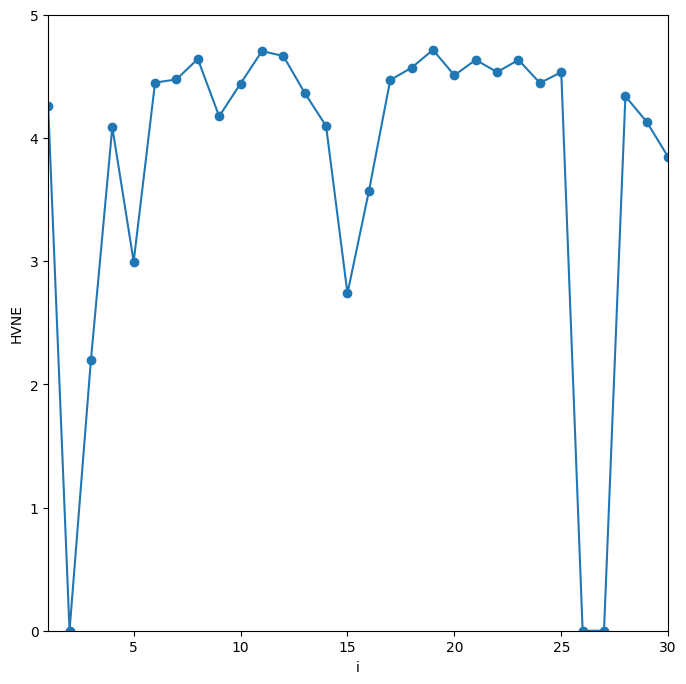

In [26]:
print(len(VNEH))
u=[]
for i in range(1,31):
    u.append(i)
plt.plot(u,VNEH)
plt.scatter(u,VNEH)
plt.xlim([1,30])
plt.ylim([0,5])
plt.xlabel("i")
plt.ylabel("HVNE")

# CURVATURE

In [27]:
W=[]
w=[]
N=[]
NTH=[]
EVO=[]
EVO_TH=[]
U=[]
FRlistP=[]
FRP=[]

for u in range(1,31):
    W.append(u)
    w.append(DATE[100*u])
    MI_set=[]
#x,y=L2[226]
    mi=mutual_info(time_series2(21,5),time_series2(22,5))
#    print(mi)


    for i in range(len(P2)):
        x,y=P1[i]
        mi=mutual_info(time_series2(x,u),time_series2(y,u))
        MI_set.append(mi)

#Writing the mutual iforamtion value into a column in a csv file

    with open(f'REAL_VALUE_BSE_CAP{u}.csv', 'w') as fm:
        writer = csv.writer(fm)
        for val in MI_set:
            writer.writerow([val])
#print(len(P2))



   
    data=[]
    with open(f'BSI100_MI_CAP_shuffled{u}.csv', 'r') as file:
      csvreader = csv.reader(file)
      for row in csvreader:
          data.append(row)

#import matplotlib.pyplot as plt

    Count=[]
    WeightMI=[]
    P_edge_index=[]
    P_edge_list=[]

    for i in range(len(MI_set)):
        count=0
        for j in range(len(data[i])):
            u=str(MI_set[i])
            v=str(data[i][j])
            if  u<v:
                count=count+1
        Count.append(count/100)
#print(len(Count))
#print(len(P))

    count2=0
    for o in range(len(Count)):
        int(Count[o])
        if Count[o]<0.05:
            count2=count2+1
            WeightMI.append(MI_set[o])
            P_edge_list.append(P2[o])
            P_edge_index.append(P1[o])
        
    N.append(count2)
    
    
    temp_degree=[]
    for i in P_edge_list:
        a,b=i
        temp_degree.append(a)
        temp_degree.append(b)
    d_dist=[]
    for i in CAP:
        d_dist.append(temp_degree.count(i))
    
    EVO.append(d_dist)
    
    
    U.append(sum(WeightMI)/(2*26))
    
    meanP=sum(WeightMI)/len(WeightMI)
    stdevP=statistics.stdev(WeightMI)
    AdjP_index=[]
    AdjP_list=[]
    Final_weightlistMI=[]
    for i in range(len(WeightMI)):
        if WeightMI[i]>meanP+0.0*stdevP:
            AdjP_index.append(P_edge_index[i])
            AdjP_list.append(P_edge_list[i])
            Final_weightlistMI.append(WeightMI[i])

    NTH.append(len(AdjP_index))
    
    
    temp_degree=[]
    for i in AdjP_list:
        a,b=i
        temp_degree.append(a)
        temp_degree.append(b)
    d_dist=[]
    for i in CAP:
        d_dist.append(temp_degree.count(i))
    EVO_TH.append(d_dist)
    
    
    FRCPE=[]

    for i in range(len(P_edge_index)):
        a,b=P_edge_index[i]
        We=WeightMI[i]
        Wi=0
        Wj=0
        sigma1=0
        sigma2=0
        for j in range(len(P_edge_index)):
            c,d=P_edge_index[j]
            if c==a:
                Wi=Wi+WeightMI[j]
            if d==b:
                Wj=Wj+WeightMI[j]
    
        Wi=Wi-WeightMI[i]
        Wj=Wj-WeightMI[i]
    
        for k in range(len(P_edge_index)):
            e,f=P_edge_index[k]
            if e==a:
                if f!=b:
                    sigma1=sigma1+(Wi/pow(We*WeightMI[k],0.5))
                
            if f==b:
                if e!=a:
                    sigma2=sigma2+(Wj/pow(We*WeightMI[k],0.5))
    
    
        frcpe=(Wi+Wj)-We*(sigma1+sigma2)
        FRCPE.append(frcpe)
    print(Wi,Wj)
    meanfrcp=sum(FRCPE)/len(FRCPE)
    FRlistP.append(FRCPE)
    FRP.append(meanfrcp)

0.0 0.8184725561704428
0.0 1.3700332919170934
0.0 2.1999985379692766
0.0 2.267531313603268
0.0 2.04712095541792
0.0 1.3745912724146452
0.0 0.46457162818581027
0.0 0.9075946502624468
0.0 1.2567048303960766
0.0 0.8443123896571954
0.0 1.116215374667263
0.0 1.116695953916889
0.0 1.0457455096601191
0.0 1.589713598808615
0.0 1.5015692018384077
0.0 1.0551191118327004
0.0 1.062802134073332
0.0 0.8005364436574068
0.0 0.2931599582446828
0.0 0.2976098946205538
0.0 0.36082297026151267
0.0 0.4055063352892032
0.0 0.5033168359899377
0.0 0.7728671855724496
0.0 0.2756142590528059
0.0 1.8213084598701266
0.0 2.5808046017208435
0.0 1.378120654965304
0.0 1.0102020823087614
0.0 0.44601791058286083


[-32.9574441746526, -50.87281908624243, -63.81205150649037, -68.37059354919712, -62.17182583587604, -44.27993338050571, -22.147664728866552, -29.35942513593456, -50.520399205073176, -41.381752463926716, -23.87015432487288, -24.37242684969594, -32.62692892982123, -44.83564688293493, -49.927145194320175, -41.287118503857414, -26.774010106584964, -21.526172810350758, -10.760033236740865, -9.521779244148856, -13.523038796713028, -18.78915942605471, -21.980463361347436, -32.65592492806253, -30.535243892325457, -79.39442840668114, -83.03026738273054, -39.390859537568716, -42.04194769099617, -29.738758236850977]


Text(0, 0.5, 'Forman-Ricci Curvature')

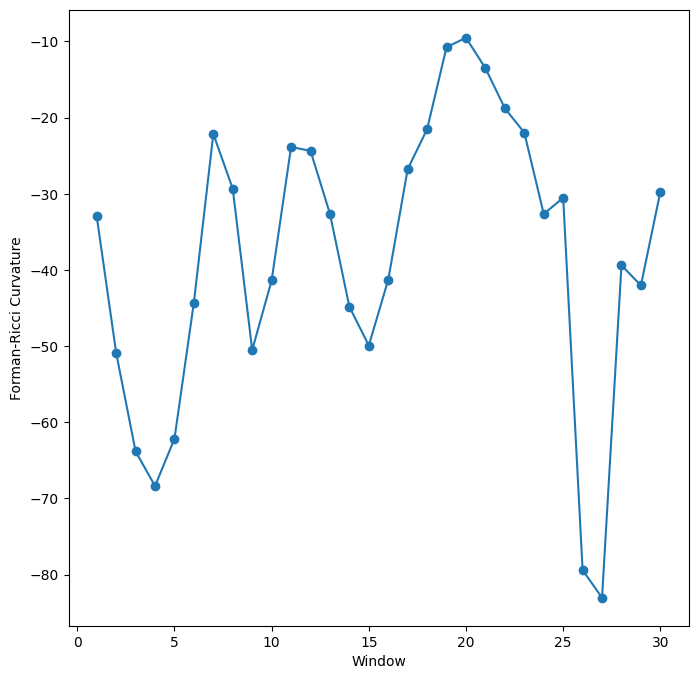

In [28]:
print(FRP)
plt.plot(W,FRP)
plt.scatter(W,FRP)
plt.xlabel('Window')
plt.ylabel('Forman-Ricci Curvature')

In [29]:
import csv
import statistics
import matplotlib.pyplot as plt
N3=[]
N3TH=[]
W=[]
EVO3=[]
EVO3_TH=[]
U1=[]

FRlistH=[]
FRH=[]

for u in range(1,31):
    W.append(u)
    II_set=[]
#x,y=L2[226]
    ii=interaction_info(time_series2(1,5),time_series2(2,5),time_series2(3,5))
    print(ii)


    for i in range(len(T1)):
        x,y,z=T1[i]
        ii=interaction_info(time_series2(x,u),time_series2(y,u),time_series2(z,u))
        II_set.append(ii)
 

#Writing the interaction information value into a column in a csv file

    with open(f'REAL_VALUE_II_BSE_CAP{u}.csv', 'w') as fi:
        writer = csv.writer(fi)
        for val in II_set:
            writer.writerow([val])

    print(len(T2),len(II_set))



#FINDING NUMBER OF SYNERGISTIC EDGES

    Synergic_edge_list=[]
    Synergic_edge_index=[]
    Synergic_edge_value=[]
    for i in range(len(II_set)):
        v=float(II_set[i])
        if v<0:
            Synergic_edge_list.append(T2[i])
            Synergic_edge_index.append(T1[i])
            Synergic_edge_value.append(v)
    print(len(Synergic_edge_index))
    
    
    
    

    if len(Synergic_edge_index)==0:
        N3.append(0)
        N3TH.append(0)
        EVO3.append(0)
        FRH.append(0)
        FRlistH.append(0)
        continue


#SHUFFLING

    j=u
#for j in range(3,15):
    II_total=[]

    for i in Synergic_edge_index:
        a,b,c=i
        II_inter=[]
        y=time_series2(b,j)
        x=time_series2(a,j)
        z=time_series2(c,j)

        for k in range(100):
            random.shuffle(x)
            random.shuffle(y)
            random.shuffle(z)
            ii=interaction_info(x,y,z)
            II_inter.append(ii)
        II_total.append(II_inter)
        with open(f'BSI100II_CAP{j}.csv', 'w', encoding='UTF8', newline='') as fpi:
            writer = csv.writer(fpi,delimiter = ',')
            writer.writerows(II_total)
        
    
    data=[]
    with open(f"BSI100II_CAP{u}.csv", 'r') as file:
      csvreader = csv.reader(file)
      for row in csvreader:
          data.append(row)

    

    Count=[]
    WeightII=[]
    H_edge_index=[]
    H_edge_list=[]
    for i in range(len(Synergic_edge_value)):
        count=0
        for j in range(100):
            u=float(Synergic_edge_value[i])
            v=float(data[i][j])
            if  u>v:
                count=count+1
        Count.append(count/100)
    print(sum(Count)/len(Count))

    count2=0
    for o in range(len(Count)):
    
        if Count[o]<0.05:
            count2=count2+1
            WeightII.append(Synergic_edge_value[o])
            H_edge_index.append(Synergic_edge_index[o])
            H_edge_list.append(Synergic_edge_list[o])
    
    N3.append(count2)
    
    U1.append(sum(WeightII)/(3*26))    
    
    
    temp_degree=[]
    for i in H_edge_list:
        a,b,c=i
        temp_degree.append(a)
        temp_degree.append(b)
        temp_degree.append(c)
    d_dist=[]
    for i in CAP:
        d_dist.append(temp_degree.count(i))
    
    EVO3.append(d_dist)
        
    
    if len(WeightII)==0:
        N3TH.append(0)
        EVO3_TH.append(0)
        FRH.append(0)
        FRlistH.append(0)
        continue
    
    print(len(WeightII))
    mean=sum(WeightII)/len(WeightII)
#    stdev=statistics.stdev(WeightII)
    AdjH_index=[]
    AdjH_list=[]
    Final_weightlistII=[]
    for i in range(len(WeightII)):
        if WeightII[i]<mean:
            AdjH_index.append(H_edge_index[i])
            AdjH_list.append(H_edge_list[i])
            Final_weightlistII.append(WeightII[i])
    N3TH.append(len(AdjH_index))

    
    temp_degree=[]
    for i in AdjH_list:
        a,b,c=i
        temp_degree.append(a)
        temp_degree.append(b)
        temp_degree.append(c)
    d_dist=[]
    for i in CAP:
        d_dist.append(temp_degree.count(i))
    
    EVO3_TH.append(d_dist)
    
    
    FRCHE=[]
    
    
    
    for i in range(len(H_edge_index)):
        a,b,c=H_edge_index[i]
        We=abs(WeightII[i])
        Wi=0
        Wj=0
        Wk=0
        sigma1=0
        sigma2=0
        sigma3=0
        
        for j in range(len(H_edge_index)):
            d,e,f=H_edge_index[j]
            if d==a:
                Wi=Wi+abs(WeightII[j])
            if e==b:
                Wj=Wj+abs(WeightII[j])
            if f==c:
                Wk=Wk+abs(WeightII[j])
            
        Wi=Wi-abs(WeightII[i])
        Wj=Wj-abs(WeightII[i])
        Wk=Wk-abs(WeightII[i])
    
        for k in range(len(H_edge_index)):
            g,h,l=H_edge_index[k]
            if g==a:
                if h!=b or l!=c:
                    sigma1=sigma1+(Wi/pow(We*abs(WeightII[k]),0.5))
                
            if h==b:
                if g!=a or l!=c:
                    sigma2=sigma2+(Wj/pow(We*abs(WeightII[k]),0.5))
            
            if l==c:
                if g!=a or h!=b:
                    sigma3=sigma3+(Wk/pow(We*abs(WeightII[k]),0.5))
        
           
    
    
        frche=(Wi+Wj+Wk)-We*(sigma1+sigma2+sigma3)
        FRCHE.append(frche)
        
    meanfrch=sum(FRCHE)/len(FRCHE)
    FRlistH.append(FRCHE)
    FRH.append(meanfrch)
    print(FRH,We)

0.022346172426187194
2600 2600
125
0.06255999999999995
79
[-2.6628248203846145] 0.011312182054718633
0.022346172426187194
2600 2600
1
0.09
0.022346172426187194
2600 2600
1
0.02
1
[-2.6628248203846145, 0, 0.0] 0.0008936789837440118
0.022346172426187194
2600 2600
101
0.06920792079207919
60
[-2.6628248203846145, 0, 0.0, -2.3810272807215664] 0.0019133838246708122
0.022346172426187194
2600 2600
10
0.037
7
[-2.6628248203846145, 0, 0.0, -2.3810272807215664, -0.07619052775345796] 0.0030153844821577285
0.022346172426187194
2600 2600
88
0.056363636363636345
61
[-2.6628248203846145, 0, 0.0, -2.3810272807215664, -0.07619052775345796, -1.9292422329479513] 0.0022859578289886467
0.022346172426187194
2600 2600
399
0.08070175438596489
216
[-2.6628248203846145, 0, 0.0, -2.3810272807215664, -0.07619052775345796, -1.9292422329479513, -22.988716866612418] 0.0020100767718004633
0.022346172426187194
2600 2600
414
0.09739130434782621
205
[-2.6628248203846145, 0, 0.0, -2.3810272807215664, -0.07619052775345796,

2600 2600
63
0.051111111111111086
47
[-2.6628248203846145, 0, 0.0, -2.3810272807215664, -0.07619052775345796, -1.9292422329479513, -22.988716866612418, -3.380534299564075, -11.00967207902834, -11.369173582336654, -11.90849641907932, -18.653025690340428, -4.30743876970925, -0.9911075681958462, -0.02877596131474325, -11.798388869875152, -0.6706862442937143, -8.426336047776273, -4.812774450592147, -1.819857485580377, -7.634910723915043, -14.515391463189031, -3.0367823112442505, -3.44048916384056, -13.861538624795337, 0, 0, -0.21312712352560945, -2.0619767186400857] 0.0008433292839398528
0.022346172426187194
2600 2600
43
0.03767441860465118
32
[-2.6628248203846145, 0, 0.0, -2.3810272807215664, -0.07619052775345796, -1.9292422329479513, -22.988716866612418, -3.380534299564075, -11.00967207902834, -11.369173582336654, -11.90849641907932, -18.653025690340428, -4.30743876970925, -0.9911075681958462, -0.02877596131474325, -11.798388869875152, -0.6706862442937143, -8.426336047776273, -4.81277445

[-2.6628248203846145, 0, 0.0, -2.3810272807215664, -0.07619052775345796, -1.9292422329479513, -22.988716866612418, -3.380534299564075, -11.00967207902834, -11.369173582336654, -11.90849641907932, -18.653025690340428, -4.30743876970925, -0.9911075681958462, -0.02877596131474325, -11.798388869875152, -0.6706862442937143, -8.426336047776273, -4.812774450592147, -1.819857485580377, -7.634910723915043, -14.515391463189031, -3.0367823112442505, -3.44048916384056, -13.861538624795337, 0, 0, -0.21312712352560945, -2.0619767186400857, -1.7290966793358462]


Text(0, 0.5, 'Forman-Ricci Curvature')

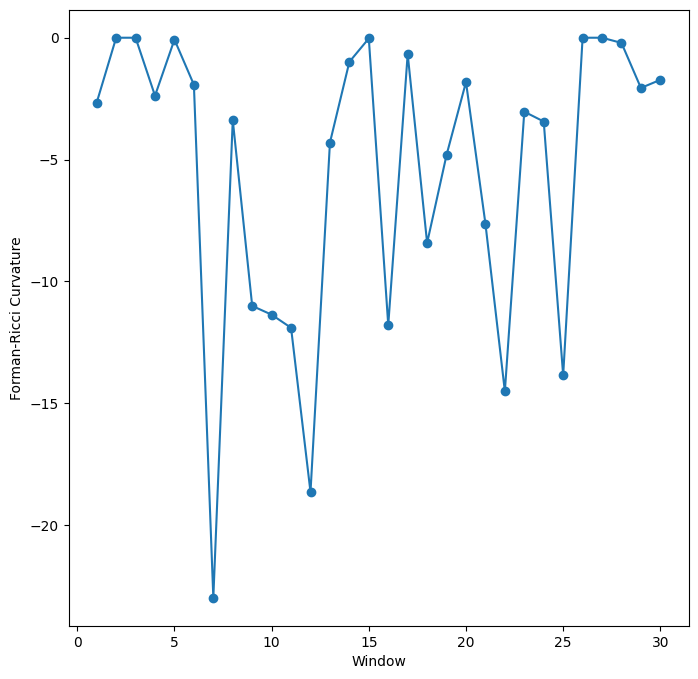

In [30]:
print(FRH)
plt.plot(W,FRH)
plt.scatter(W,FRH)
plt.xlabel('Window')
plt.ylabel('Forman-Ricci Curvature')

# VARIABILITY COMPARISON

# EDGE NUMBER

In [32]:
import statistics as st

In [31]:
N_listP=[]
N_listH=[]
for i in range(30):
    N_listP.append(len(ADJ_P_LIST_ALL[i]))
    N_listH.append(len(ADJH_LIST_ALL[i]))

In [33]:
st.stdev(N_listH)/st.mean(N_listH)

0.9644311288483131

In [34]:
st.stdev(VNE)/st.mean(VNE)

0.011504029699401598

# CURVATURE wieghted(not considering)

In [85]:
FRP

[-32.9574441746526,
 -50.87281908624243,
 -63.81205150649037,
 -68.37059354919712,
 -62.17182583587604,
 -44.27993338050571,
 -22.147664728866552,
 -29.35942513593456,
 -50.520399205073176,
 -41.381752463926716,
 -23.87015432487288,
 -24.37242684969594,
 -32.62692892982123,
 -44.83564688293493,
 -49.927145194320175,
 -41.287118503857414,
 -26.774010106584964,
 -21.526172810350758,
 -10.760033236740865,
 -9.521779244148856,
 -13.523038796713028,
 -18.78915942605471,
 -21.980463361347436,
 -32.65592492806253,
 -30.535243892325457,
 -79.39442840668114,
 -83.03026738273054,
 -39.390859537568716,
 -42.04194769099617,
 -29.738758236850977]

# VON NEUMANN ENTROPY

In [35]:
V=[]
for j in range(1,31):
    v=statistics.stdev(fc[I][100*(j-2)+100:100*(j)+99])
    V.append(v)

NameError: name 'COMPANY_EVCP' is not defined

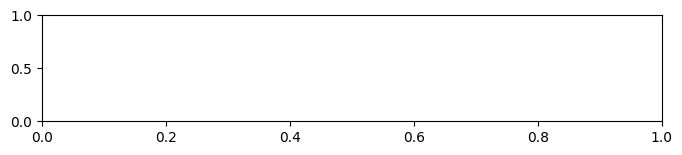

In [36]:
#2.VECTOR CENTRALITY
plt.subplot(5, 1, 2)
plt.plot(u,COMPANY_EVCP,color='red',label='pairwise')
plt.plot(u,COMPANY_EVCH,color='blue',label='triangular')
#plt.plot(u,log_series,color='yellow',label='log gains average')
plt.scatter(u,COMPANY_EVCP,color='red')
plt.scatter(u,COMPANY_EVCH,color='blue')
#plt.scatter(u,log_series,color='yellow')
#plt.plot(d,Returns)
plt.xlim([0,29])
#plt.title("VECTOR CENTRALITY")
plt.legend()


#3.VON NEUMANN ENTROPY

plt.subplot(5, 1, 3)
plt.plot(u,VNE,color='red',label='pairwise')
plt.plot(u,VNEH,color='blue',label='triangular')
#plt.plot(u,log_series,color='yellow',label='log gains average')
plt.scatter(u,VNE,color='red')
plt.scatter(u,VNEH,color='blue')
#plt.scatter(u,log_series,color='yellow')
#plt.plot(d,Returns)
plt.xlim([0,29])
#plt.title("VON NEUMANN ENTROPY")
plt.legend()

#4.CURVATURE

plt.subplot(5, 1, 4)
plt.plot(u,FRP,color='red',label='pairwise')
plt.plot(u,FRH,color='blue',label='triangular')
#plt.plot(u,log_series,color='yellow',label='log gains average')
plt.scatter(u,FRP,color='red')
plt.scatter(u,FRH,color='blue')
#plt.scatter(u,log_series,color='yellow')
#plt.plot(d,Returns)
plt.xlim([0,29])
#plt.title("FORMAN RICCI CURVATURE")
plt.legend()


#1.TIME SERIES
plt.subplot(5,1,1)
plt.plot(d,Returns)
plt.xlim([0,3145])
plt.title(Companies[T_index])

#5.VOLATILITY

plt.subplot(5,1,5)
plt.plot(u,V)
plt.scatter(u,V)
plt.xlim([0,29])
#plt.title(CAP[I])

# VECTOR CENTRALITY COMPARISON EMPHASIS

In [ ]:
CAP=['RIL IB Equity','TCS IB Equity', 'HDFCB IB Equity','INFO IB Equity','HUVR IB Equity','ICICIBC IB Equity','HDFC IB Equity','SBIN IB Equity','ITC IB Equity','BHARTI IB Equity','BJFIN IB Equity','KMB IB Equity','HCLT IB Equity','LT IB Equity','AXSB IB Equity','MSIL IB Equity', 'SUNP IB Equity','WPRO IB Equity','TTAN IB Equity','UTCEM IB Equity','ADE IB Equity','ONGC IB Equity','NEST IB Equity','MM IB Equity','NTPC IB Equity','PWGR IB Equity']
Infotech=['TCS IB Equity','INFO IB Equity','HCLT IB Equity','WPRO IB Equity']
Energy=['RIL IB Equity','ADE IB Equity','ONGC IB Equity','NTPC IB Equity']
Materials=['LT IB Equity','UTCEM IB Equity']
Industrials=[]
Utilities=['PWGR IB Equity']
Healthcare=['SUNP IB Equity']
Financials=['ICICIBC IB Equity','HDFC IB Equity','SBIN IB Equity','HDFCB IB Equity','BJFIN IB Equity','AXSB IB Equity']
Consumer_Discretionary=['MSIL IB Equity','TTAN IB Equity','MM IB Equity']
Consumer_Staples=['HUVR IB Equity','ITC IB Equity','NEST IB Equity']
Communication_Services=['BHARTI IB Equity']
Real_Estate=[]

I=CAP.index('NTPC IB Equity')
print(CAP[I])
COMPANY_EVCP=[]
COMPANY_EVCH=[]
u=[]
d=[]
Returns=[]
for i in range(30):
    u.append(i)
    COMPANY_EVCP.append(EIGEN_VECTOR_ALL[i][I])
    COMPANY_EVCH.append(VECTOR_CENTRALITY_ALL[i][I])

for j in range(len(Companies)):
    if CAP[I]==Companies[j]:
        T_index=j
        
for k in range(len(fc[T_index])):
    Returns.append(fc[T_index][k])
    d.append(k)


#2.VECTOR CENTRALITY
plt.plot(u,COMPANY_EVCP,color='red',label='pairwise')
plt.plot(u,COMPANY_EVCH,color='blue',label='triangular')
#plt.plot(u,log_series,color='yellow',label='log gains average')
plt.scatter(u,COMPANY_EVCP,color='red')
plt.scatter(u,COMPANY_EVCH,color='blue')
#plt.scatter(u,log_series,color='yellow')
#plt.plot(d,Returns)
plt.xlim([0,29])
#plt.title("VECTOR CENTRALITY")
plt.legend()
#plt.axvline(x=2,linestyle='dotted')
plt.axvline(x=14,linestyle='dotted')
#plt.axvline(x=15,linestyle='dotted')
plt.axvline(x=22,linestyle='dotted')
plt.axvline(x=26,linestyle='dotted')
plt.axvline(x=30,linestyle='dotted')

plt.title(CAP[I])

# AVERAGE VOLATILITY VS AVERAGE CORRELATION

In [ ]:
for i in range(len(WEIGHTII_ALL)):
    if WEIGHTII_ALL[i]==0:
        WEIGHTII_ALL[i]=[]

In [ ]:
VOL_avg=[]
for i in range(1,31):
    V=[]
    for j in range(len(CAP)):
        u1=time_series2(j,i)
        v=statistics.stdev(u1)
        V.append(v)
    VOL_avg.append(V)
MI_avg=[]
II_avg=[]
for i in range(30):
    a=WEIGHTII_ALL[i]
    b=WEIGHTMI_ALL[i]
    print(a)
    if len(a)==0:
        II_avg.append(0)
    else:
        II_avg.append(sum(a)/len(a))
    MI_avg.append(sum(b)/len(b))

In [ ]:
AVG_VOL=[]
for i in range(30):
    AVG_VOL.append(sum(VOL_avg[i])/26)

In [ ]:
SCALED_VOL=[]
SCALED_II=[]
for i in range(30):
    SCALED_VOL.append(10*AVG_VOL[i])
    SCALED_II.append(-10*II_avg[i])

In [ ]:
#plt.plot(u,AVG_VOL)
#plt.scatter(u,AVG_VOL)
plt.xlim([0,29])
plt.plot(u,MI_avg,color='red',label='AVERAGE MI')
plt.scatter(u,MI_avg,color='red')
#plt.plot(u,II_avg)
#plt.scatter(u,II_avg)
plt.plot(u,SCALED_VOL,color='blue',label='AVERAGE VOLATILITY')
plt.scatter(u,SCALED_VOL,color='blue')
plt.plot(u,SCALED_II,color='green',label='AVERAGE II')
plt.scatter(u,SCALED_II,color='green')
plt.legend()
plt.axvline(x=2,linestyle='dotted')
plt.axvline(x=14,linestyle='dotted')
#plt.axvline(x=15,linestyle='dotted')
plt.axvline(x=22,linestyle='dotted')
plt.axvline(x=26,linestyle='dotted')
plt.axvline(x=30,linestyle='dotted')

# AVERAGE VALUES AND NUMBER OF EDGES

In [ ]:
H_length=[]
P_length=[]
for i in range(30):
    H_length.append(len(ADJH_INDEX_ALL_TH[i]))
    P_length.append(len(ADJ_P_LIST_ALL_TH[i]))

In [ ]:
f = open('AVERAGE_VALUES_BSE.dat', 'w')
for i in range(len(MI_avg)):
    print(i,MI_avg[i],SCALED_II[i],SCALED_VOL[i] , file=f)
f.close()

In [ ]:
#1.EDGE LENGTH STATS

#PLOTS
plt.subplot(2,1,1)
plt.xlim([0,29])
plt.plot(u,H_length)
plt.plot(u,P_length)
plt.scatter(u,H_length)
plt.scatter(u,P_length)

#MARKING THE CRASH PERIODS
plt.axvline(x=2,linestyle='dotted')
plt.axvline(x=14,linestyle='dotted')
#plt.axvline(x=15,linestyle='dotted')
plt.axvline(x=22,linestyle='dotted')
plt.axvline(x=26,linestyle='dotted')
plt.axvline(x=30,linestyle='dotted')


#2.AVERAGE CORRELATION STATS

#PLOTS
plt.subplot(2,1,2)
plt.xlim([0,29])
plt.plot(u,MI_avg,color='red',label='AVERAGE MI')
plt.scatter(u,MI_avg,color='red')
plt.plot(u,SCALED_VOL,color='blue',label='AVERAGE VOLATILITY')
plt.scatter(u,SCALED_VOL,color='blue')
plt.plot(u,SCALED_II,color='green',label='AVERAGE II')
plt.scatter(u,SCALED_II,color='green')
plt.legend()


#MARKING THE CRASH PERIODS
plt.axvline(x=2,linestyle='dotted')
plt.axvline(x=14,linestyle='dotted')
#plt.axvline(x=15,linestyle='dotted')
plt.axvline(x=22,linestyle='dotted')
plt.axvline(x=26,linestyle='dotted')
plt.axvline(x=30,linestyle='dotted')

# 3D PROJECTION

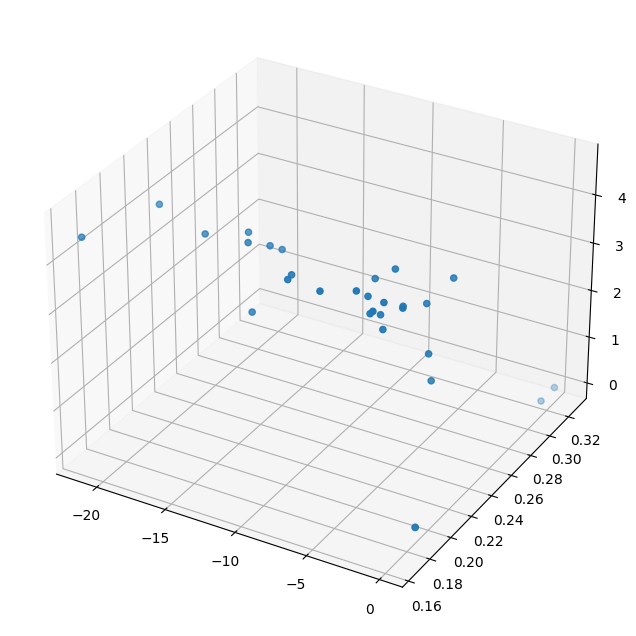

In [120]:
ax = plt.axes(projection='3d')
ax.scatter3D(FRH, SCALED_VOL, VNEH);

# DETECTING OUTLIERS

In [121]:
A=sum(VNEH)/len((MI_avg))
B=sum(SCALED_VOL)/len(SCALED_VOL)
C=sum(VNEH)/len(SCALED_II)
AVG=[A,B,C]
P=[]
for i in range(30):
    P.append((FRH[i],SCALED_VOL[i],VNEH[i]))
DIST=[]
for i in range(30):
    dist=math.dist(P[i],AVG)
    DIST.append(dist)

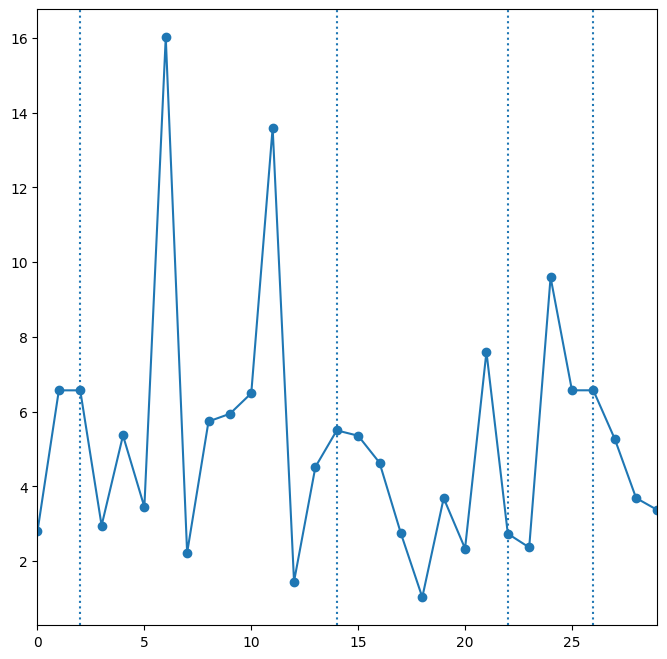

In [122]:
plt.plot(u,DIST)
plt.scatter(u,DIST)
plt.xlim([0,29])
plt.axvline(x=2,linestyle='dotted')
plt.axvline(x=14,linestyle='dotted')
#plt.axvline(x=15,linestyle='dotted')
plt.axvline(x=22,linestyle='dotted')
plt.axvline(x=26,linestyle='dotted')
plt.axvline(x=30,linestyle='dotted')

# INTER SECTOR CORRELATIONS AS LONG RANGE CORRELATIONS


# COMMUNITY STRUCTURE

In [ ]:
Infotech=['TCS IB Equity','INFO IB Equity','HCLT IB Equity','WPRO IB Equity']
Energy=['RIL IB Equity','ADE IB Equity','ONGC IB Equity','NTPC IB Equity']
Materials=['LT IB Equity','UTCEM IB Equity']
Industrials=[]
Utilities=['PWGR IB Equity']
Healthcare=['SUNP IB Equity']
Financials=['ICICIBC IB Equity','HDFC IB Equity','SBIN IB Equity','HDFCB IB Equity','BJFIN IB Equity','AXSB IB Equity']
Consumer_Discretionary=['MSIL IB Equity','TTAN IB Equity','MM IB Equity']
Consumer_Staples=['HUVR IB Equity','ITC IB Equity','NEST IB Equity']
Communication_Services=['BHARTI IB Equity']
Real_Estate=[]

STRUCTURE=[Infotech,Energy,Materials,Industrials,Utilities,Healthcare,Financials,Consumer_Discretionary,Consumer_Staples,Communication_Services,Real_Estate]

# PAIRWISE

In [ ]:
interlink_count=[]
intralink_count=[]
for i in range(len(ADJ_P_LIST_ALL)):
    interlink=0
    intralink=0
    for j in range(len(ADJ_P_LIST_ALL[i])):
        a,b=ADJ_P_LIST_ALL[i][j]
        for k in STRUCTURE:
            if (a in k or b in k):
                if (a in k and b in k):
                    intralink=intralink+1
                    break;
                else:
                    interlink=interlink+1
                    break;
    interlink_count.append(interlink)
    intralink_count.append(intralink)
        

In [ ]:
for i in range(30):
    print(len(ADJ_P_INDEX_ALL[i]),interlink_count[i],intralink_count[i],intralink_count[i]+interlink_count[i])

# HIGHER ORDER

In [ ]:
interlink_countH=[]
intralink_countH=[]
for i in range(len(ADJH_LIST_ALL)):
    interlinkH=0
    intralinkH=0
    for j in range(len(ADJH_LIST_ALL[i])):
        a,b,c=ADJH_LIST_ALL[i][j]
        
        for k in STRUCTURE:
            
            if (a in k or b in k or c in k):
                
                if (a in k and b in k and c in k):
                    
                    intralinkH=intralinkH+1
                    
                    break;
                else:
                    interlinkH=interlinkH+1
                    break;
    interlink_countH.append(interlinkH)
    intralink_countH.append(intralinkH)

In [ ]:
for i in range(30):
    print(len(ADJH_INDEX_ALL[i]),interlink_countH[i],intralink_countH[i],intralink_countH[i]+interlink_countH[i])